# QUEST 2
__Bar Char__

In [282]:
import pandas as pd
import sqlite3

database_path = "../data/checking-logs.sqlite"

In [283]:
try:
    connection = sqlite3.connect(database_path)
except Exception:
    print("Не удалось подключиться к СУБД :(")

_When do our users usually commit the labs: in the night, morning, afternoon, or evening?_

## 1) analyze only the users and not the admins

In [284]:
query = """
select timestamp from checker
where uid like 'user_%'
"""
df = pd.io.sql.read_sql(query, connection, parse_dates="timestamp")

## 2) Range

night is from 0:00:00 to 03:59:59, morning is from 04:00:00 to 09:59:59, afternoon is from 10:00:00 to 16:59:59, evening is from 17:00:00 to 23:59:59

In [285]:
df["daytime"] = pd.cut(df["timestamp"].dt.hour, bins=[0, 4, 10, 17, 24], right=False, labels=["night", "morning", "afternoon", "evening"], ordered=True)
df["timestamp"] = df["timestamp"].dt.date
df["commits"] = df["timestamp"]
display(df)

,timestamp,daytime,commits
0,2020-04-17,morning,2020-04-17
1,2020-04-17,morning,2020-04-17
2,2020-04-17,morning,2020-04-17
3,2020-04-17,morning,2020-04-17
4,2020-04-17,morning,2020-04-17
...,...,...,...
3202,2020-05-21,evening,2020-05-21
3203,2020-05-21,evening,2020-05-21
3204,2020-05-21,evening,2020-05-21
3205,2020-05-21,evening,2020-05-21


In [286]:
g = df.groupby(["timestamp", "daytime"]).count()
df = g.pivot_table(index="timestamp", columns="daytime", values="commits")
print(len(df))

35


In [287]:
display(g)

commits
timestamp  daytime           
2020-04-17 night            0
           morning         13
           afternoon       10
           evening          0
2020-04-18 night            0
...                       ...
2020-05-20 evening         10
2020-05-21 night            0
           morning          1
           afternoon       27
           evening         21

[140 rows x 1 columns]

In [288]:
display(df)

daytime,night,morning,afternoon,evening
timestamp,,,,
2020-04-17,0,13,10,0
2020-04-18,0,1,33,35
2020-04-19,2,4,16,11
2020-04-20,0,0,12,13
2020-04-21,0,0,0,25
2020-04-22,0,0,4,24
2020-04-23,2,6,15,20
2020-04-24,0,0,4,12
2020-04-25,1,21,33,49


## 3) Plotting

* the fontsize and the figsize are still the same
* choose a palette that you really enjoy, you do not have to replicate it from the graph above

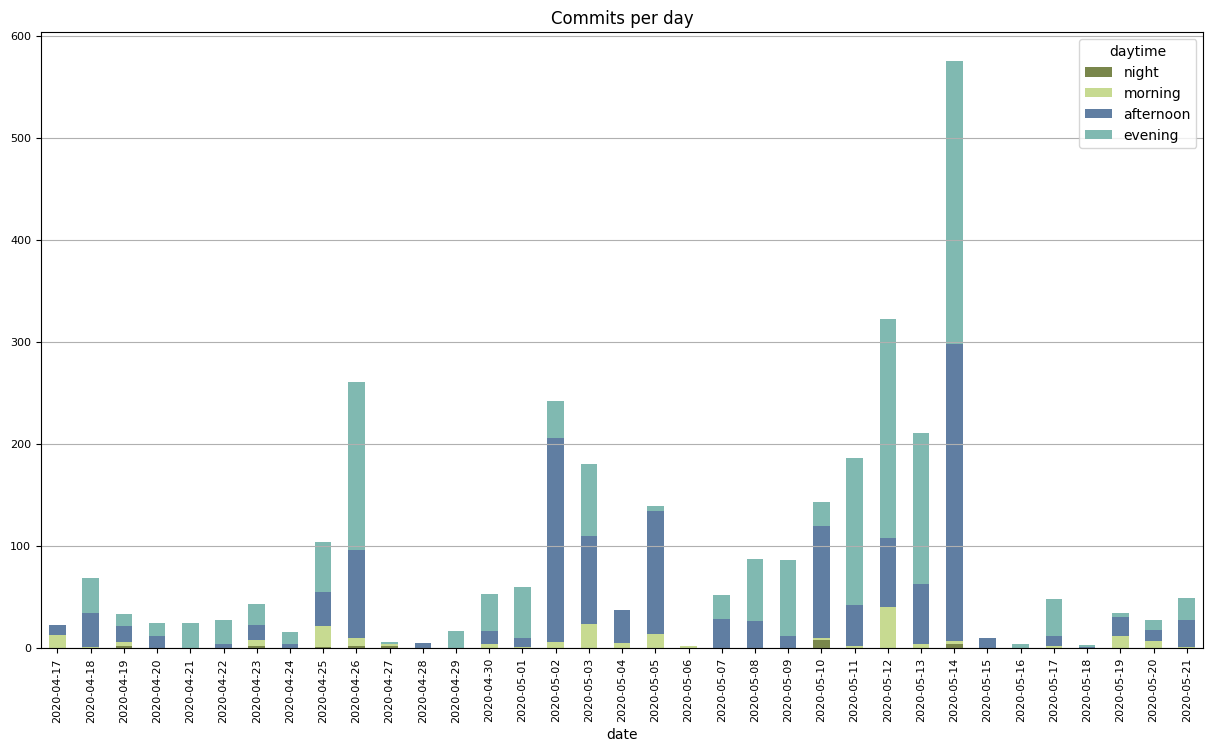

In [289]:
pic = df.plot(kind="bar", title="Commits per day", fontsize=8, 
              figsize=(15, 8), rot=90, stacked=True, xlabel="date", 
              color=("#79864b", "#c7da91", "#607ea2", "#80b9b1"))
pic.grid(axis="y")

## Questions

### When do our users usually commit the labs: in the night, morning, afternoon, or evening?

-- __evening__ (визуально)
Проверим вычислительно:

In [290]:
# проверка
for column in df.columns:
    print(f"{column}: {df[column].sum()}")

night: 21
morning: 184
afternoon: 1391
evening: 1611


## Which day has:

* the most number of commits
* and at the same time, the number of commits in the evening is higher than in the afternoon? 
-- __12.05.2020 или 14.05.2020__ (визуально)


Проверим кодом:

In [291]:
max_date = ""
max_count = -1
for index, date in df.iterrows():
    if date["evening"] > date["afternoon"]:
        cur_count = date["night"] + date["morning"] + date["evening"] + date["afternoon"]
        if max_count < cur_count:
            max_count = cur_count
            max_date = index

print(max_date)

2020-05-12


__Ответ:__ 2020-05-12

In [292]:
connection.close()